<a target="_blank" href="https://github.com/aldebaro/ml-ufpa/tree/main/nb_dos_caras_safos/Decision_stump/ml_602_decision_stump_v2.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This code implements a Decision Stump as a DecisionTreeClassifier of depth = 1.

Aldebaro. 2020-12-19.

If you are using Colab, run the cell below to upload your datasets

In [ ]:
from google.colab import files

print("Please, upload the dataset file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

In [3]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load training data
# This data is in https://nextcloud.lasseufpa.org/s/eirR4bqKKP9xxRe?path=%2Fcode%2Fml-ufpa%2Fdatasets
# Use any data for this example in this repository
# Make sure this data is in the same folder as the code
def load(arquivo):
    filename = f'{arquivo}.csv'
    my_data = np.genfromtxt(filename, delimiter=',')
    X = my_data[:,:2]
    y = np.ravel(my_data[:,2:], order='C')
    return X, y

Automatically created module for IPython interactive environment
feature 0 , values and corresponding labels
[10.  11.  12.  13.  13.8 14.  14. ]
[1. 1. 0. 1. 0. 0. 0.]
feature 1 , values and corresponding labels
[0.5 1.  1.5 1.8 2.4 2.8 3.2]
[1. 1. 0. 1. 0. 0. 0.]

The fitted decision stump:
|--- feature_0 <= 13.40
|   |--- class: 1.0
|--- feature_0 >  13.40
|   |--- class: 0.0

correct labels= [0. 1. 0. 0. 1. 0. 1.]
predictions= [1. 1. 0. 0. 1. 0. 1.]


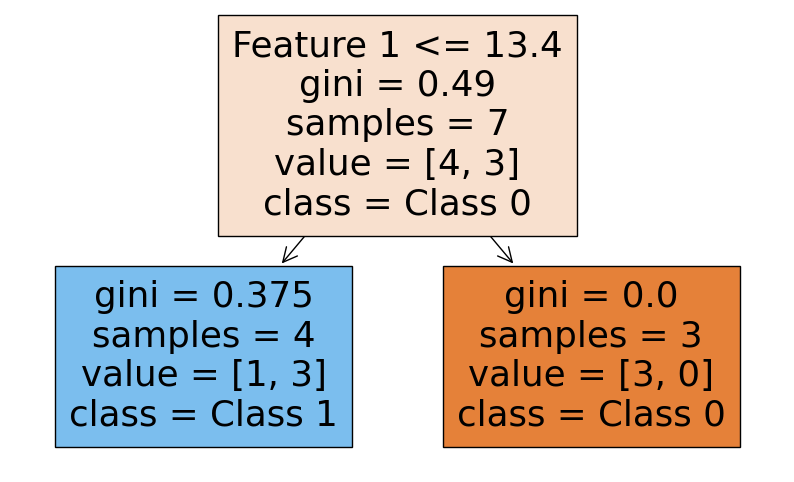

In [5]:
arquivo = input("Please, enter the name of the .csv file you want to use: ")
print(__doc__)

X, y = load(arquivo)

input_dimension = X.shape
if len(input_dimension) != 2:
    raise Exception('Input must be 2D')

num_features = input_dimension[1]
for k in range(num_features):
    print('feature', k, ', values and corresponding labels')
    sorted_indices = np.argsort(X[:,k])
    print(X[sorted_indices,k])
    print(y[sorted_indices])

sample_weight = np.ones(y.shape, dtype=float)

decision_stump = DecisionTreeClassifier(max_depth=1, min_samples_leaf=1, criterion='gini')
decision_stump.fit(X, y, sample_weight)

print('\nThe fitted decision stump:')
r = export_text(decision_stump)
print(r)

print('correct labels=', y)
print('predictions=', decision_stump.predict(X))

plt.figure(figsize=(10, 6))
plot_tree(decision_stump, filled=True, feature_names=['Feature 1', 'Feature 2'], class_names=['Class 0', 'Class 1'])
plt.show()